# 은든헬스 — 사용자 플로우 다이어그램

헬스장 이용자의 앱 진입부터 주간 운동 계획 화면까지의 사용자 행동/화면 이동/의사결정 흐름을 Mermaid로 시각화한다.

- **렌더링**: [mermaid.ink](https://mermaid.ink) 원격 API로 그래프를 이미지로 변환
- **출력**: matplotlib으로 표시하고 선택적으로 PNG 저장

In [9]:
# 이 노트북이 실제로 사용하는 패키지만 설치한다.
%pip install requests pillow matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import base64
import io

import requests
from PIL import Image
import matplotlib.pyplot as plt


def render_mermaid(graph: str, theme: str = "default") -> Image.Image:
    """Mermaid 그래프를 mermaid.ink로 렌더링해 PIL 이미지로 반환한다."""
    encoded = base64.urlsafe_b64encode(graph.encode("utf-8")).decode("ascii")
    url = f"https://mermaid.ink/img/{encoded}?theme={theme}"

    response = requests.get(url, timeout=30)
    response.raise_for_status()  # HTTP 오류면 여기서 명확히 실패한다.

    try:
        return Image.open(io.BytesIO(response.content))
    except Exception as exc:
        # mermaid.ink는 문법 오류 시 이미지가 아닌 오류 응답을 돌려준다.
        # (대표 원인: 노드 ID에 공백 포함, 라벨 안 괄호 등)
        raise ValueError(
            "Mermaid 렌더링에 실패했습니다. 그래프 문법을 확인하세요.\n"
            f"응답 일부: {response.text[:300]}"
        ) from exc


def show_mermaid(graph: str, theme: str = "default", save_path: str | None = None) -> None:
    """그래프를 렌더링해 화면에 표시하고, save_path가 있으면 PNG로 저장한다."""
    img = render_mermaid(graph, theme)

    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis("off")
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

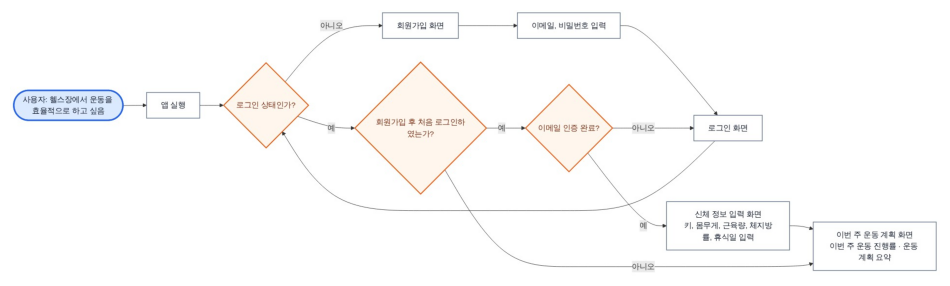

In [13]:
# =========================================================
# USER FLOW DIAGRAM
# 관점: 사용자 행동 / 화면 이동 / 의사결정 / 예외 처리
# 주의: 노드 ID에는 공백을 쓸 수 없다(BodyInfo 등 영문 ID 사용).
#       Mermaid 주석은 '#'이 아니라 '%%'를 쓴다.
# =========================================================
USER_FLOW = """
flowchart LR
    Start([사용자: 헬스장에서 운동을 효율적으로 하고 싶음])

    Start --> Landing[앱 실행]
    Landing --> LoginCheck{로그인 상태인가?}

    %% 회원가입 후 로그인 페이지로 이동
    LoginCheck -- 아니오 --> Signup[회원가입 화면]
    Signup --> Profile[이메일, 비밀번호 입력]
    Profile --> Loginpage[로그인 화면]
    Loginpage --> LoginCheck

    LoginCheck -- 예 --> ResumeCheck{회원가입 후 처음 로그인하였는가?}

    %% 이메일 인증 확인 후 신체 정보 입력 화면 이동
    ResumeCheck -- 예 --> VerifyCheck{이메일 인증 완료?}
    VerifyCheck -- 아니오 --> Loginpage
    VerifyCheck -- 예 --> BodyInfo[신체 정보 입력 화면<br/>키, 몸무게, 근육량, 체지방률, 휴식일 입력]
    BodyInfo --> Dashboard
    ResumeCheck -- 아니오 --> Dashboard

    Dashboard[이번 주 운동 계획 화면<br/>이번 주 운동 진행률 · 운동 계획 요약]

%% =========================================================

    classDef start fill:#dbeafe,stroke:#2563eb,stroke-width:3px,color:#0f172a;
    classDef screen fill:#ffffff,stroke:#64748b,stroke-width:1.5px,color:#0f172a;
    classDef decision fill:#fff7ed,stroke:#ea580c,stroke-width:2px,color:#7c2d12;

    class Start start;
    class Landing,Signup,Profile,Loginpage,BodyInfo,Dashboard screen;
    class LoginCheck,ResumeCheck,VerifyCheck decision;
"""

show_mermaid(USER_FLOW, save_path="user-flow-diagram.png")